<a href="https://colab.research.google.com/github/dorakue042-cell/toola/blob/main/Report/IMISToolA2026_Report4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Report 4 (2026/07/27 ver.A)

for Tools for intelligent interaction systems a (0ALE005 / 0AL5707).

---

* Student ID: 202620800
* Name: 永戸皐幹
* Colab account: nagato@fz.iit.tsukuba.ac.jp
---

Report could be written in English or Japanese. / レポートの記述は日本語でも英語でもよい．

---

---
# Report4A: Live capture query with CIFAR-10 or MNIST  

* Show the way to build a classfier of CIFAR10 or MNIST.
* Provide a python program that captures an image from a camera and that shows its recognition result of the image immediately.

Hint: Each shown in tutorials. Find a way to unite them.



In [ ]:
print ('You can put code cells and text cells around here.')

In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

print("Training data:", x_train.shape)
print("Test data:", x_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training data: (60000, 28, 28)
Test data: (10000, 28, 28)


In [4]:
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

x_train = x_train[..., np.newaxis]
x_test = x_test[..., np.newaxis]

print(x_train.shape)

(60000, 28, 28, 1, 1)


In [5]:
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(28, 28, 1)),

    tf.keras.layers.Conv2D(32, (3, 3), activation="relu"),
    tf.keras.layers.MaxPooling2D((2, 2)),

    tf.keras.layers.Conv2D(64, (3, 3), activation="relu"),
    tf.keras.layers.MaxPooling2D((2, 2)),

    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(64, activation="relu"),
    tf.keras.layers.Dense(10, activation="softmax")
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       102,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 121,930 (476.29 KB)

 Trainable params: 121,930 (476.29 KB)

 Non-trainable params: 0 (0.00 B)

In [6]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history = model.fit(
    x_train,
    y_train,
    epochs=5,
    validation_split=0.1
)

Epoch 1/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 34s 19ms/step - accuracy: 0.7644 - loss: 0.7235 - val_accuracy: 0.9303 - val_loss: 0.2381
Epoch 2/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 40s 19ms/step - accuracy: 0.9254 - loss: 0.2465 - val_accuracy: 0.9538 - val_loss: 0.1569
Epoch 3/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 32s 19ms/step - accuracy: 0.9499 - loss: 0.1659 - val_accuracy: 0.9698 - val_loss: 0.1069
Epoch 4/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 40s 18ms/step - accuracy: 0.9626 - loss: 0.1236 - val_accuracy: 0.9740 - val_loss: 0.0949
Epoch 5/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 31s 19ms/step - accuracy: 0.9697 - loss: 0.1001 - val_accuracy: 0.9765 - val_loss: 0.0812


In [8]:
from google.colab import files

uploaded = files.upload()

filename = list(uploaded.keys())[0]
print("Uploaded file:", filename)

Saving IMG_5427.jpeg to IMG_5427.jpeg
Uploaded file: IMG_5427.jpeg


Saving IMG_5427.jpg to IMG_5427.jpg
filename: IMG_5427.jpg
画像サイズ: (3024, 3024, 3)


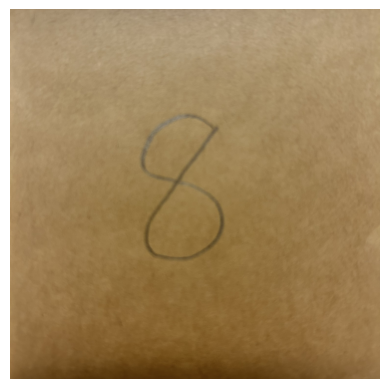

In [13]:
from google.colab import files
import cv2
import matplotlib.pyplot as plt

# 画像をアップロード
uploaded = files.upload()

# アップロードされたファイル名を取得
filename = next(iter(uploaded))

print("filename:", filename)

# 画像を読み込む
img = cv2.imread(filename)

# 読み込み確認
if img is None:
    print("画像を読み込めませんでした")
else:
    print("画像サイズ:", img.shape)

    # BGR → RGB
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # 表示
    plt.imshow(img_rgb)
    plt.axis("off")
    plt.show()

In [14]:
import numpy as np

def preprocess_image(filename):
    # 画像読み込み
    img = cv2.imread(filename)

    # グレースケール化
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # 28×28に変換
    gray = cv2.resize(gray, (28, 28))

    # 白背景・黒文字を、黒背景・白文字に反転
    gray = 255 - gray

    # 0～1に正規化
    gray = gray.astype("float32") / 255.0

    # CNNへの入力形式 (1, 28, 28, 1)
    input_image = gray.reshape(1, 28, 28, 1)

    return gray, input_image

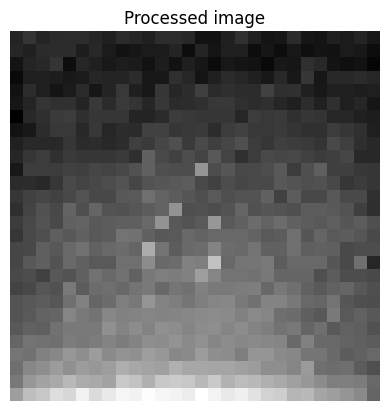

In [15]:
processed_image, input_image = preprocess_image(filename)

plt.imshow(processed_image, cmap="gray")
plt.title("Processed image")
plt.axis("off")
plt.show()

Recognition result: 4
Confidence: 100.0%


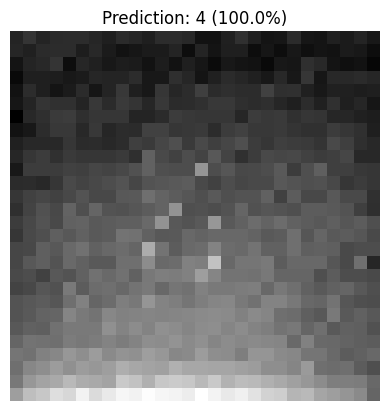

In [16]:
prediction = model.predict(input_image, verbose=0)

predicted_class = np.argmax(prediction)
confidence = np.max(prediction)

print("Recognition result:", predicted_class)
print(f"Confidence: {confidence * 100:.1f}%")

plt.imshow(processed_image, cmap="gray")
plt.title(
    f"Prediction: {predicted_class} "
    f"({confidence * 100:.1f}%)"
)
plt.axis("off")
plt.show()

(You can put text cells around here)

---
# Report4B: Tutorials of pytorch

There are [many tutorials](https://github.com/kameda-yoshinari/IMISToolExeA2021/blob/master/300_PyTorch.ipynb) provided by the Pytorch official site. Pick up **two tutorials** (you should complete those tutorials) and make a report for the two tutorials on:

* Summary (2-3 lines)
* What you learn
* The most difficult part

Note that you are encouraged to choose the recommended two .


---
# Report4C: AI support to learn python and PyTorch  

Find out the state-of-the-art AI support which is available / helpful on learning how to write python / pytorch codes on google colab.
Then write your own comment on what kind of changes would happen in a couple of years.

* AI service name
* AI service "official web site"
* Major funcitons of provided support
* The service start date and version history (including the URL that holds such info)


(You can put text cells around here)

---
# Report submission

As for Report4, in addition to submit this ipynb, you are also asked to submit 801_miniGPT.ipynb and 802_miniGPT.ipnyb (in total of three files).

You should save this file as a report templete to your local google colaboratory folder and then edit it to fit your report.

The report submission should be made at this cource (0ALE005) at https://manaba.tsukuba.ac.jp .  
Note that 0AL5707 is coupled with 0ALE005 on manaba system, so 0AL5707 students should also submit the report at 0ALE005.  
File extension should be **ipynb**. Other format won't be accepted.  







---
Tools and Practices for Intelligent Interaction Systems A  
Master's and Docotal programs in intelligent and mechanical interaction systems, University of Tsukuba, Japan.  
KAMEDA Yoshinari, SHIBUYA Takeshi  

知能システムツール演習a  
知能機能システム学位プログラム (筑波大学大学院)  
担当：亀田能成，澁谷長史  

2026/07/27. Ver.B. 説明簡略化 / Simplified Explanation  
2026/07/27. Ver.A.  


